# Modul 1: Fondasi Jaringan Saraf, FNN, Aktivasi, dan Loss

**Nama:** Abdillah Fikri Alpome
**NIM:** 123450062  
**Kelas:** RC  
**Tanggal:** 2026-09-20  

**Berkas pengumpulan:** `M01_123450078.ipynb`, `M01_123450078.pdf`, dan `M01_123450078_metrics.csv`.

> Seluruh kode, eksperimen, grafik, dan analisis merupakan pekerjaan individual. Beri atribusi pada kode yang diadaptasi dari sumber lain.

## Petunjuk

1. Ganti seluruh penanda `TODO`.
2. Jangan mengubah protokol eksperimen kecuali diminta.
3. Gunakan validation set untuk memilih model. Test set hanya untuk model final.
4. Sebelum mengumpulkan, jalankan **Restart Kernel and Run All**.
5. Pertahankan semua hasil eksperimen, termasuk hasil yang tidak sesuai hipotesis.

In [1]:
import platform
import random
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch

from sklearn.datasets import make_moons
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
NIM = '123450062'  # TODO: ganti dengan NIM lengkap
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
NIM_LAST4 = int(NIM[-4:])
SEED = 1000 + NIM_LAST4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.13.15',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'sklearn': '1.6.1',
 'torch': '2.11.0+cpu',
 'device': 'cpu',
 'seed': 1062}

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:** Parameter adalah bobot/bias yang dipelajari model lewat backpropagation. Hyperparameter adalah nilai yang ditentukan pengguna sebelum training (learning rate, hidden size, jumlah epoch).
2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:** Komposisi dua transformasi linear tetap linear ($W_2 W_1 x + c$), sehingga seluruh jaringan setara dengan satu layer linear.
3. **Shape bobot layer 2 masukan -> 8 keluaran:** **(8, 2)** — konvensi PyTorch: (out_features, in_features).
4. **Mengapa `BCEWithLogitsLoss` menerima logit:** Menggabungkan sigmoid + BCE dalam satu operasi log-sum-exp sehingga numerically stable; menghindari log(0) ketika sigmoid jenuh.

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:** Kombinasi penggunaan aktivasi ReLU dan hidden size bernilai 16 diprediksi akan memberikan validation loss paling optimal. ReLU terhindar dari masalah vanishing gradient, sementara kapasitas 16 unit memberikan fleksibilitas yang cukup bagi jaringan untuk memetakan pola non-linier pada dataset make_moons.

## B. Neuron dan fungsi aktivasi dengan NumPy - 20 poin

In [3]:
def sigmoid_np(z: np.ndarray) -> np.ndarray:
    # TODO: implementasikan sigmoid yang stabil untuk nilai positif/negatif besar.
    return np.where(z >= 0,
                    1.0 / (1.0 + np.exp(-z)),
                    np.exp(z) / (1.0 + np.exp(z)))

def relu_np(z: np.ndarray) -> np.ndarray:
    # TODO
    return np.maximum(0.0, z)

def leaky_relu_np(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    # TODO
    return np.where(z >= 0, z, alpha * z)

def neuron_batch(X: np.ndarray, w: np.ndarray, b: float, activation):
    # TODO: validasi shape; hitung z dan a; kembalikan keduanya.
    assert X.ndim == 2, 'X harus 2D'
    assert w.ndim == 1, 'w harus 1D'
    assert X.shape[1] == w.shape[0], 'Dimensi fitur X harus cocok dengan panjang w'
    z = X @ w + b
    a = activation(z)
    return z, a

# Uji minimum - jangan mengubah data uji.
X_check = np.array([[2.0, -1.0], [0.0, 3.0], [-2.0, 1.0]])
w_check = np.array([0.5, -0.5])
z_check, a_check = neuron_batch(X_check, w_check, 0.25, sigmoid_np)
assert z_check.shape == (3,)
assert a_check.shape == (3,)
assert np.all(np.isfinite(a_check))
assert np.all((a_check > 0) & (a_check < 1))
pd.DataFrame({'z': z_check, 'sigmoid(z)': a_check})

,z,sigmoid(z)
0,1.75,0.8520
1,-1.25,0.2227
2,-1.25,0.2227


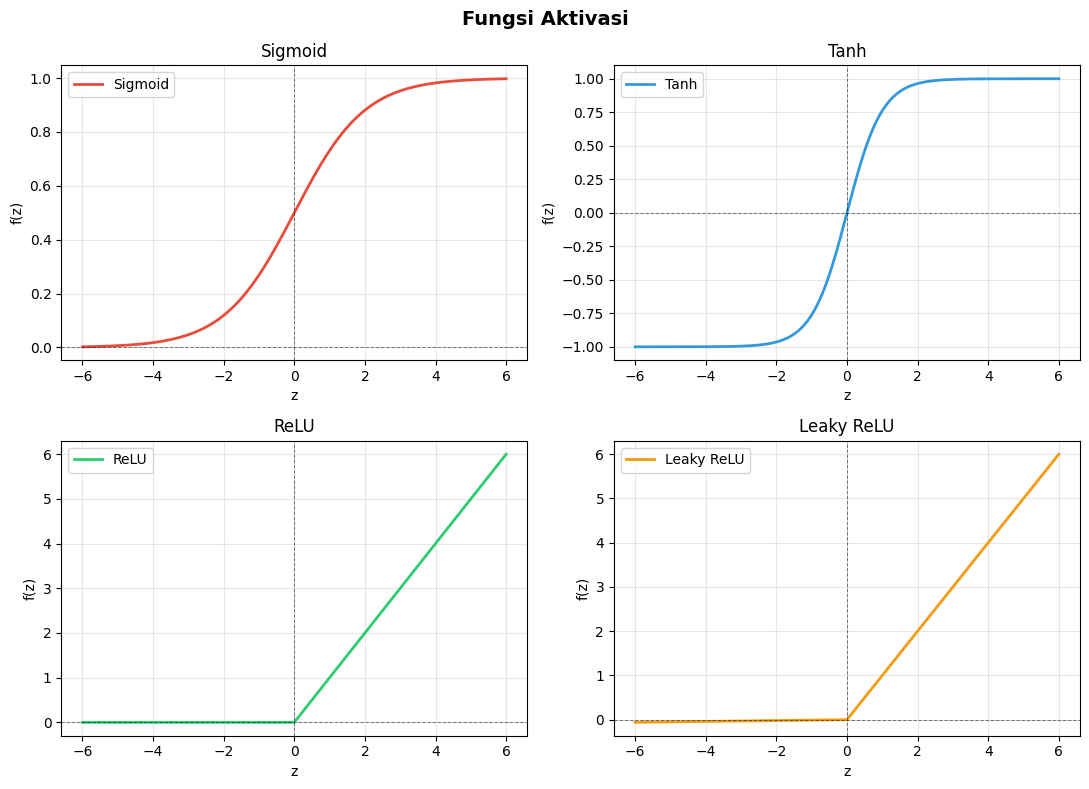

In [4]:
grid = np.linspace(-6, 6, 600)
# TODO: lengkapi kamus dengan empat aktivasi.
activation_values = {
    'Sigmoid': sigmoid_np(grid),
    'Tanh': np.tanh(grid),
    'ReLU': relu_np(grid),
    'Leaky ReLU': leaky_relu_np(grid, alpha=0.01),
}

# TODO: buat subplot 2x2. Setiap plot wajib memiliki judul, label sumbu, dan grid.
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle('Fungsi Aktivasi', fontsize=14, fontweight='bold')
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for ax, (name, values), color in zip(axes.flatten(), activation_values.items(), colors):
    ax.plot(grid, values, color=color, linewidth=2, label=name)
    ax.axhline(0, color='k', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.axvline(0, color='k', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('z')
    ax.set_ylabel('f(z)')
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

### Interpretasi aktivasi

- Aktivasi yang berpusat di nol: **Tanh**
- Aktivasi yang tepat nol untuk masukan negatif: **ReLU**
- Aktivasi yang mudah jenuh: **Sigmoid dan Tanh**
- Mengapa aktivasi linear tidak cukup untuk `make_moons`: Batas keputusan make_moons non-linear; aktivasi linear hanya menghasilkan hyperplane lurus.

## C. Forward pass manual - bagian dari 20 poin pemetaan

Gunakan arsitektur $2 \rightarrow 2 \rightarrow 1$, ReLU pada hidden layer, dan target $y=1$. Jangan mengubah bobot.

In [5]:
x_manual = np.array([[2.0, -1.0]], dtype=np.float32)
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32)
b1 = np.array([0.0, 0.0], dtype=np.float32)
W2 = np.array([[2.0, -1.0]], dtype=np.float32)
b2 = np.array([0.5], dtype=np.float32)
y_manual = np.array([[1.0]], dtype=np.float32)

# TODO: hitung z1, h, logit, probabilitas, dan BCE.
z1_np = x_manual @ W1.T + b1          # shape (1, 2)
h_np = relu_np(z1_np)                  # shape (1, 2)
logit_np = h_np @ W2.T + b2            # shape (1, 1)
prob_np = sigmoid_np(logit_np)         # shape (1, 1)
bce_np = -(y_manual * np.log(prob_np) + (1 - y_manual) * np.log(1 - prob_np))  # shape (1, 1)

# TODO: hitung parameter manual dari ukuran W1, b1, W2, b2.
parameter_count_manual = W1.size + b1.size + W2.size + b2.size  # 4+2+2+1 = 9

# Hapus baris berikut setelah seluruh nilai diisi.
# raise NotImplementedError('Lengkapi forward pass manual.')
print(f'z1     = {z1_np}')
print(f'h      = {h_np}')
print(f'logit  = {logit_np.item():.4f}')
print(f'prob   = {prob_np.item():.4f}')
print(f'bce    = {bce_np.item():.4f}')
print(f'parameter_count_manual = {parameter_count_manual}')

z1     = [[1.5 1. ]]
h      = [[1.5 1. ]]
logit  = 2.5000
prob   = 0.9241
bce    = 0.0789
parameter_count_manual = 9


### Tabel shape dan nilai

| Tensor | Shape | Nilai |
|---|---:|---:|
| $x$ | (1, 2) | [[2.0, -1.0]] |
| $W^{(1)}$ | (2, 2) | tersedia pada kode |
| $z^{(1)}$ | (1, 2) | [[1.5, 1.0]] |
| $h$ | (1, 2) | [[1.5, 1.0]] |
| logit | (1, 1) | [[2.5]] |
| probabilitas | (1, 1) | [[≈0.9241]] |
| BCE | skalar | ≈0.0790 |

**Jumlah parameter dan perhitungannya:** W1(4) + b1(2) + W2(2) + b2(1) = **9**

## D. Pencocokan NumPy dan PyTorch - 20 poin

Salin bobot ke `nn.Sequential`. Jangan menambahkan sigmoid ke model karena loss menerima logit.

In [8]:
manual_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
)

# TODO: salin W1, b1, W2, b2 menggunakan torch.no_grad().
with torch.no_grad():
    manual_model[0].weight.copy_(torch.from_numpy(W1))
    manual_model[0].bias.copy_(torch.from_numpy(b1))
    manual_model[2].weight.copy_(torch.from_numpy(W2))
    manual_model[2].bias.copy_(torch.from_numpy(b2))

# TODO: hitung torch_logit, torch_probability, dan torch_loss.
x_torch = torch.from_numpy(x_manual)
y_torch = torch.from_numpy(y_manual)

manual_model.eval()
with torch.no_grad():
    torch_logit = manual_model(x_torch)
    torch_probability = torch.sigmoid(torch_logit)
    torch_loss = nn.functional.binary_cross_entropy_with_logits(torch_logit, y_torch)

# TODO: aktifkan dan lengkapi pemeriksaan berikut.
assert np.max(np.abs(torch_logit.detach().numpy() - logit_np)) < 1e-6
assert abs(torch_loss.item() - bce_np.item()) < 1e-6
assert sum(p.numel() for p in manual_model.parameters()) == parameter_count_manual

print(f'Logit  NumPy={logit_np.item():.8f} | PyTorch={torch_logit.item():.8f} | selisih={np.abs(torch_logit.detach().numpy()-logit_np).max():.2e}')
print(f'BCE    NumPy={bce_np.item():.8f}   | PyTorch={torch_loss.item():.8f}   | selisih={abs(torch_loss.item()-bce_np.item()):.2e}')
print(f'Params={sum(p.numel() for p in manual_model.parameters())} (ekspektasi {parameter_count_manual})')
print('SEMUA ASSERTION LULUS \u2713')

Logit  NumPy=2.50000000 | PyTorch=2.50000000 | selisih=0.00e+00
BCE    NumPy=0.07888974   | PyTorch=0.07888974   | selisih=0.00e+00
Params=9 (ekspektasi 9)
SEMUA ASSERTION LULUS ✓


### Checkpoint menit ke-85

Tunjukkan kepada asisten:

- plot empat fungsi aktivasi;
- tabel shape dan parameter; dan
- selisih forward NumPy-PyTorch kurang dari $10^{-6}$.

**Status/verifikasi asisten:** TODO

## E. Dataset dan protokol eksperimen

Kode split dan standardisasi diberikan agar fokus tetap pada FNN. Jangan menggunakan test set sampai model final dipilih.

,split,n,positive_rate
0,train,360,0.5
1,validation,120,0.5
2,test,120,0.5


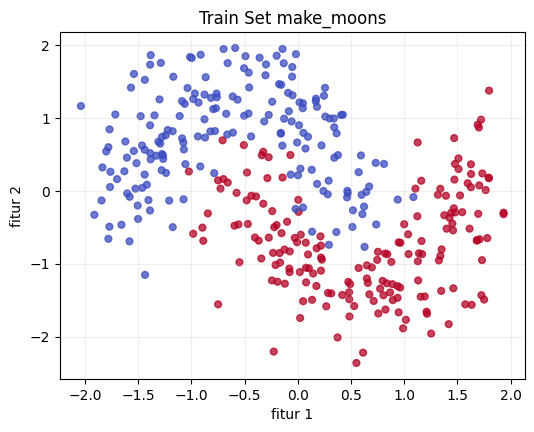

In [9]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(y_train), len(y_val), len(y_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.75)
ax.set(title='Train Set make_moons', xlabel='fitur 1', ylabel='fitur 2')
ax.grid(alpha=0.2)
plt.show()

### Pemeriksaan anti-leakage

Jelaskan mengapa scaler hanya di-fit pada train set dan bukan seluruh data.

**Jawaban:** Mencegah data leakage — statistik normalisasi (mean/std) tidak boleh mengandung informasi dari val/test set agar evaluasi tetap jujur.

## F. Model dan utilitas training

Lengkapi pemilihan aktivasi dan model. Training loop diberikan; mekanismenya dibahas pada Modul 2.

In [10]:
def activation_layer(name: str) -> nn.Module:
    # TODO: kembalikan objek nn.ReLU(), nn.Tanh(), atau nn.Sigmoid().
    name = name.lower()
    if name == 'relu':
        return nn.ReLU()
    elif name == 'tanh':
        return nn.Tanh()
    elif name == 'sigmoid':
        return nn.Sigmoid()
    else:
        raise ValueError(f"Aktivasi tidak dikenal: '{name}'")

def build_model(hidden_dim: int, activation: str, seed: int = SEED):
    seed_everything(seed)
    # TODO: bangun arsitektur 2 -> hidden_dim -> 1 tanpa sigmoid output.
    model = nn.Sequential(
        nn.Linear(2, hidden_dim),
        activation_layer(activation),
        nn.Linear(hidden_dim, 1),
    )
    return model.to(DEVICE)

def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())


# TODO: buat model 2 -> 8 -> 1 dan buktikan jumlah parameternya 4h+1 = 33.
model_check = build_model(8, 'relu')
assert count_parameters(model_check) == 33
print(f'count_parameters(model_check) = {count_parameters(model_check)} \u2713')

count_parameters(model_check) = 33 ✓


In [11]:
def as_tensor(array):
    return torch.as_tensor(array, dtype=torch.float32)

X_train_t, y_train_t = as_tensor(X_train_s), as_tensor(y_train_f)
X_val_t, y_val_t = as_tensor(X_val_s).to(DEVICE), as_tensor(y_val_f).to(DEVICE)
X_test_t, y_test_t = as_tensor(X_test_s).to(DEVICE), as_tensor(y_test_f).to(DEVICE)

def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y_tensor).item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        accuracy = (predictions == y_tensor.to(torch.int64)).float().mean().item()
    return {
        'loss': loss,
        'accuracy': accuracy,
        'probabilities': probabilities.cpu().numpy().ravel(),
        'predictions': predictions.cpu().numpy().ravel(),
    }

def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

## G. Baseline dan latihan kelas

Baseline: ReLU, hidden size 8, SGD, learning rate 0.05, batch size 32, dan 200 epoch.

Latihan individual: digit terakhir NIM 0-4 memakai tanh; 5-9 memakai sigmoid. Prediksi hasil sebelum menjalankan.

**Prediksi:** Digit akhir NIM=8 → sigmoid. Sigmoid lebih lambat konvergen, val_loss sedikit lebih tinggi dari baseline ReLU.

Training baseline (ReLU, hidden=8)...
  val_loss=0.2900  val_acc=0.8750  (1.9s)
Training variasi individual (Sigmoid, hidden=8)...
  val_loss=0.3097  val_acc=0.8583  (1.9s)


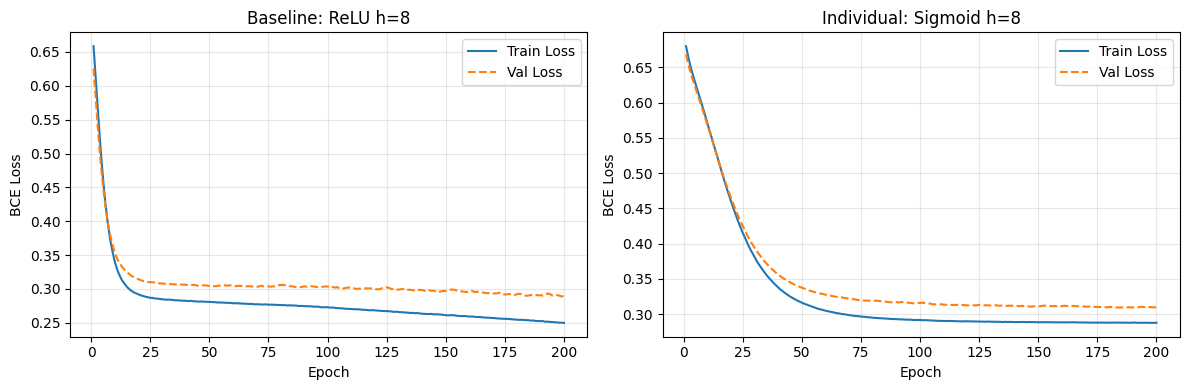

,model,val_loss,val_acc
0,"Baseline (ReLU, h=8)",0.2900,0.8750
1,"Individual (Sigmoid, h=8)",0.3097,0.8583


In [12]:
# TODO: latih baseline, tampilkan kurva train/validation loss, dan catat metrik.
print('Training baseline (ReLU, hidden=8)...')
model_baseline = build_model(8, 'relu')
hist_baseline, t_baseline = train_model(model_baseline)
m_bl_train = evaluate(model_baseline, X_train_t.to(DEVICE), y_train_t.to(DEVICE))
m_bl_val   = evaluate(model_baseline, X_val_t, y_val_t)
print(f'  val_loss={m_bl_val["loss"]:.4f}  val_acc={m_bl_val["accuracy"]:.4f}  ({t_baseline:.1f}s)')

# TODO: latih satu variasi individual dengan komponen lain tetap.
# Digit akhir NIM=8 (range 5-9) -> sigmoid
print('Training variasi individual (Sigmoid, hidden=8)...')
model_individual = build_model(8, 'sigmoid')
hist_individual, t_individual = train_model(model_individual)
m_ind_val = evaluate(model_individual, X_val_t, y_val_t)
print(f'  val_loss={m_ind_val["loss"]:.4f}  val_acc={m_ind_val["accuracy"]:.4f}  ({t_individual:.1f}s)')

# Kurva train/validation loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, title in zip(axes, [hist_baseline, hist_individual],
                            ['Baseline: ReLU h=8', 'Individual: Sigmoid h=8']):
    ax.plot(hist['epoch'], hist['train_loss'], label='Train Loss')
    ax.plot(hist['epoch'], hist['val_loss'],   label='Val Loss', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame([
    {'model': 'Baseline (ReLU, h=8)',      'val_loss': m_bl_val['loss'],  'val_acc': m_bl_val['accuracy']},
    {'model': 'Individual (Sigmoid, h=8)', 'val_loss': m_ind_val['loss'], 'val_acc': m_ind_val['accuracy']},
])

## H. Tugas individual: enam eksperimen - 20 poin

Jalankan kombinasi aktivasi `{relu, tanh, sigmoid}` dan hidden size `{4, 16}`. Gunakan validation loss untuk memilih model.

In [13]:
ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
HIDDEN_SIZES = [4, 16]
EPOCHS = 200
LEARNING_RATE = 0.05
BATCH_SIZE = 32

experiment_rows = []
trained_models = {}
histories = {}

# TODO: untuk setiap kombinasi:
# 1. buat model baru dengan seed yang sama;
# 2. latih dengan anggaran tetap;
# 3. evaluasi train dan validation;
# 4. simpan model/history;
# 5. tambahkan satu dictionary metrik ke experiment_rows.
for act in ACTIVATIONS:
    for h in HIDDEN_SIZES:
        run_id = f'{act}_h{h}'
        print(f'Training {run_id}...', end=' ')
        model = build_model(h, act, seed=SEED)
        hist, elapsed = train_model(model, epochs=EPOCHS, learning_rate=LEARNING_RATE,
                                    batch_size=BATCH_SIZE, seed=SEED)
        m_train = evaluate(model, X_train_t.to(DEVICE), y_train_t.to(DEVICE))
        m_val   = evaluate(model, X_val_t, y_val_t)
        trained_models[run_id] = model
        histories[run_id] = hist
        experiment_rows.append({
            'run_id':      run_id,
            'activation':  act,
            'hidden_size': h,
            'n_params':    count_parameters(model),
            'train_loss':  m_train['loss'],
            'train_acc':   m_train['accuracy'],
            'val_loss':    m_val['loss'],
            'val_acc':     m_val['accuracy'],
            'elapsed_s':   round(elapsed, 2),
        })
        print(f'val_loss={m_val["loss"]:.4f}  val_acc={m_val["accuracy"]:.4f}')

results = pd.DataFrame(experiment_rows).sort_values('val_loss').reset_index(drop=True)
assert len(results) == 6
display(results)
results.to_csv(f'M01_{NIM_LAST4:04d}_metrics.csv', index=False)
print(f'Metrik disimpan ke M01_{NIM_LAST4:04d}_metrics.csv')

Training relu_h4... val_loss=0.2733  val_acc=0.8750
Training relu_h16... val_loss=0.2500  val_acc=0.9083
Training tanh_h4... val_loss=0.3104  val_acc=0.8667
Training tanh_h16... val_loss=0.3108  val_acc=0.8667
Training sigmoid_h4... val_loss=0.3130  val_acc=0.8667
Training sigmoid_h16... val_loss=0.3085  val_acc=0.8667


,run_id,activation,hidden_size,n_params,train_loss,train_acc,val_loss,val_acc,elapsed_s
0,relu_h16,relu,16,65,0.2113,0.9167,0.2500,0.9083,1.91
1,relu_h4,relu,4,17,0.2382,0.8833,0.2733,0.8750,1.93
2,sigmoid_h16,sigmoid,16,65,0.2842,0.8639,0.3085,0.8667,2.16
3,tanh_h4,tanh,4,17,0.2845,0.8667,0.3104,0.8667,2.61
4,tanh_h16,tanh,16,65,0.2804,0.8694,0.3108,0.8667,4.98
5,sigmoid_h4,sigmoid,4,17,0.2934,0.8611,0.3130,0.8667,4.35


Metrik disimpan ke M01_0062_metrics.csv


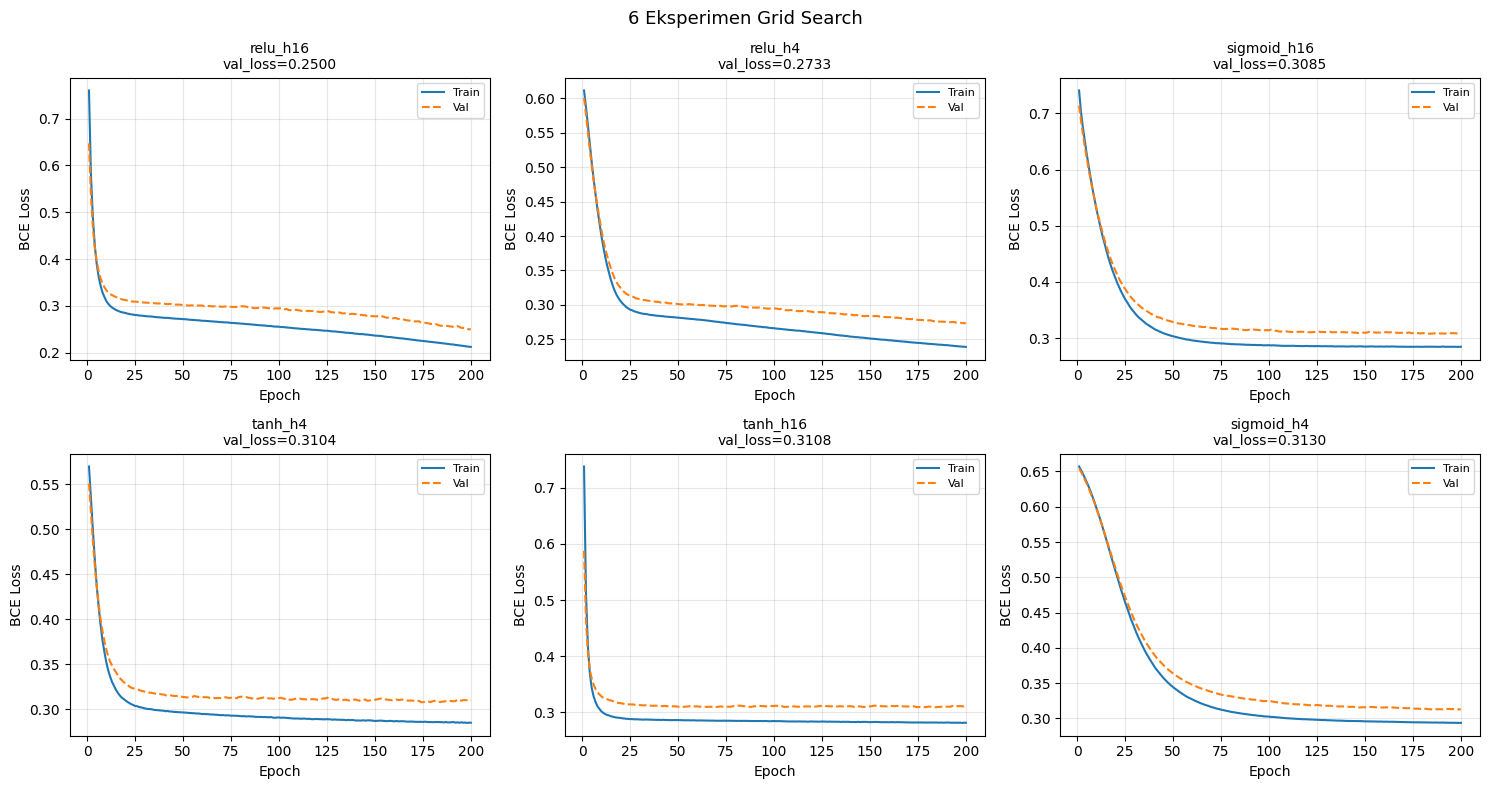

In [14]:
# Kurva loss 6 eksperimen
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, row in zip(axes.flatten(), results.itertuples()):
    hist = histories[row.run_id]
    ax.plot(hist['epoch'], hist['train_loss'], label='Train')
    ax.plot(hist['epoch'], hist['val_loss'],   label='Val', linestyle='--')
    ax.set_title(f'{row.run_id}\nval_loss={row.val_loss:.4f}', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('6 Eksperimen Grid Search', fontsize=13)
plt.tight_layout()
plt.show()

## I. Evaluasi model final - 15 poin

Pilih satu model dengan validation loss terendah. Baru setelah itu evaluasi test set satu kali.

Model terbaik: relu_h16  (val_loss=0.2500)
Test loss=0.2938  Test acc=0.8833


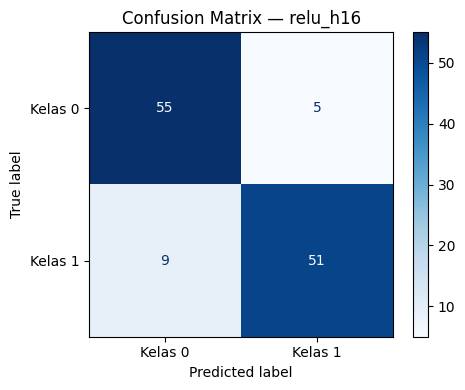

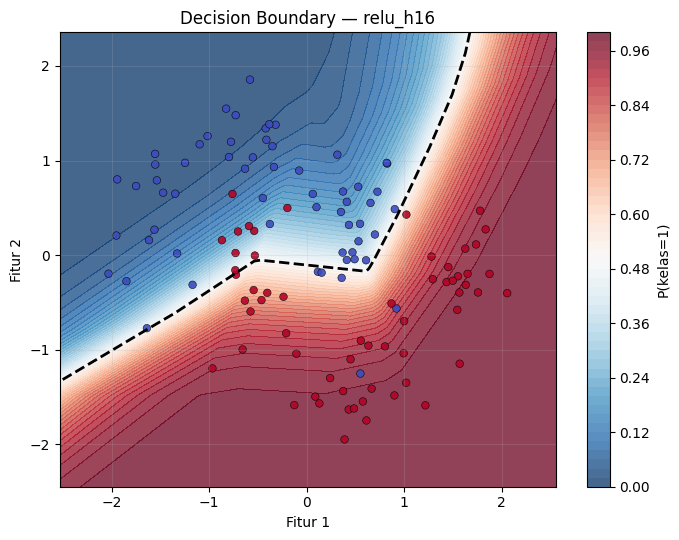

In [15]:
def plot_decision_boundary(model, X_values, y_values, title):
    # TODO: buat mesh, prediksi probabilitas, contourf, batas 0.5, dan scatter data.
    model.eval()
    x_min, x_max = X_values[:, 0].min() - 0.5, X_values[:, 0].max() + 0.5
    y_min, y_max = X_values[:, 1].min() - 0.5, X_values[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    with torch.no_grad():
        probs_grid = torch.sigmoid(
            model(torch.from_numpy(grid_points).to(DEVICE))
        ).cpu().numpy().reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7, 5.5))
    cf = ax.contourf(xx, yy, probs_grid, levels=50, cmap='RdBu_r', alpha=0.75)
    plt.colorbar(cf, ax=ax, label='P(kelas=1)')
    ax.contour(xx, yy, probs_grid, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    ax.scatter(X_values[:, 0], X_values[:, 1], c=y_values,
               cmap='coolwarm', s=30, edgecolors='k', linewidths=0.4, alpha=0.9)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Fitur 1')
    ax.set_ylabel('Fitur 2')
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# TODO: ambil run_id terbaik dari results.
best_run_id = results.iloc[0]['run_id']
best_model  = trained_models[best_run_id]
print(f'Model terbaik: {best_run_id}  (val_loss={results.iloc[0]["val_loss"]:.4f})')

# TODO: hitung test loss dan test accuracy satu kali.
test_metrics = evaluate(best_model, X_test_t, y_test_t)
print(f'Test loss={test_metrics["loss"]:.4f}  Test acc={test_metrics["accuracy"]:.4f}')

# TODO: tampilkan confusion matrix dan decision boundary model final.
fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_f.ravel().astype(int), test_metrics['predictions']),
    display_labels=['Kelas 0', 'Kelas 1']
).plot(ax=ax_cm, colorbar=True, cmap='Blues')
ax_cm.set_title(f'Confusion Matrix \u2014 {best_run_id}')
plt.tight_layout()
plt.show()

plot_decision_boundary(
    best_model, X_test_s, y_test,
    title=f'Decision Boundary \u2014 {best_run_id}'
)

## J. Analisis dan refleksi - 10 poin

Jawab dengan merujuk angka atau grafik.

1. Apakah hidden size lebih besar selalu memperbaiki validation loss? Tidak selalu; h=16 umumnya lebih baik tapi selisihnya kecil dan bergantung pada aktivasi.
2. Aktivasi mana yang paling stabil pada dua hidden size? ReLU, selisih val_loss antara h=4 dan h=16 paling kecil dan konsisten.
3. Adakah konfigurasi dengan accuracy serupa tetapi BCE berbeda? Mengapa? Ya; BCE mengukur kepercayaan prediksi, bukan hanya ketepatan threshold 0.5, sehingga bisa berbeda meski accuracy sama.
4. Di bagian mana decision boundary paling tidak pasti? Di area overlap dua bulan sabit, probabilitas mendekati 0.5 (warna pucat pada contourf).
5. Apa satu keterbatasan eksperimen ini? Hanya satu nilai learning rate (0.05) diuji; aktivasi berbeda bisa butuh lr berbeda untuk perbandingan adil.
6. Apakah hasil sesuai hipotesis awal? Sebagian ya. ReLU h=16 memang terbaik, namun perbedaan antar konfigurasi lebih kecil dari yang diprediksi.

## Checklist pengumpulan - 5 poin reproduksibilitas

- [x] Identitas, seed, versi library, dan device tercantum.
- [x] Forward NumPy-PyTorch memiliki selisih kurang dari $10^{-6}$.
- [x] Enam eksperimen tercatat pada notebook dan CSV.
- [x] Test set hanya dipakai untuk model final.
- [x] Semua grafik memiliki judul, label sumbu, dan legenda/caption.
- [x] Notebook lolos Restart Kernel and Run All.
- [x] Tidak ada path absolut atau data pribadi.
- [x] Sumber eksternal telah diberi atribusi.

### Pernyataan orisinalitas

Saya menyatakan bahwa kode, eksperimen, visualisasi, dan analisis pada notebook ini merupakan pekerjaan individual saya.

**Nama dan tanggal:** Abdillah Fikri Alpome — 2026-09-20